# 4. Model Training

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import joblib
import shap

d:\anaconda3\envs\ml-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.1 Load Processed Data

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((21114, 21), (5279, 21), (21114,), (5279,))

## 4.2 Logistic Regression

In [3]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4370
           1       1.00      1.00      1.00       909

    accuracy                           1.00      5279
   macro avg       1.00      1.00      1.00      5279
weighted avg       1.00      1.00      1.00      5279

ROC-AUC: 1.0


## 4.3 Feature Coefficients

In [4]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coef_df

,feature,coefficient
19,merchant_id_freq,-7.529161
2,receiver_account_age,-3.807992
3,receiver_transaction_history,-3.074768
7,time_between_link_click_and_transaction,1.458352
16,request_acceptance_rate,1.216981
17,time_to_respond_to_request,1.186969
0,amount,0.822212
18,user_id_freq,0.404880
20,device_id_freq,-0.370537
10,input_pause_patterns,0.342822


## 4.4 Check merchant_id_freq for Leakage

In [5]:
check_df = pd.concat([X_train['merchant_id_freq'], y_train], axis=1)
check_df.groupby('merchant_id_freq')['is_fraud'].agg(['count', 'mean']).sort_index()

,count,mean
merchant_id_freq,,
-1.715814,3636,1.0
-1.477922,28,0.0
-1.240029,117,0.0
-1.002137,324,0.0
-0.764244,550,0.0
-0.526352,1386,0.0
-0.288459,1645,0.0
-0.050567,2056,0.0
0.187326,2277,0.0


## 4.5 Check user_id_freq and device_id_freq for Leakage

In [6]:
for col in ['user_id_freq', 'device_id_freq']:
    check_df = pd.concat([X_train[col], y_train], axis=1)
    print(f"\n{col}:")
    print(check_df.groupby(col)['is_fraud'].agg(['count', 'mean']).sort_index())


user_id_freq:
              count      mean
user_id_freq                 
-1.831342       297  0.218855
-1.423962      1182  0.159898
-1.016581      2592  0.158565
-0.609200      3724  0.175081
-0.201819      4035  0.164064
 0.205562      3408  0.178404
 0.612943      2499  0.184474
 1.020324      1360  0.180882
 1.427705       783  0.159642
 1.835086       400  0.175000
 2.242466       330  0.163636
 2.649847       168  0.214286
 3.057228       143  0.160839
 3.464609        42  0.166667
 3.871990        45  0.177778
 4.279371        32  0.125000
 4.686752        17  0.294118
 5.094133        18  0.111111
 5.501513        19  0.157895
 5.908894        20  0.250000

device_id_freq:
                count      mean
device_id_freq                 
-1.761606        1541  0.798183
-1.290682        1440  0.125694
-0.819757        2979  0.120510
-0.348833        3888  0.116770
 0.122092        4165  0.119568
 0.593016        3024  0.131614
 1.063940        2058  0.134111
 1.534865        106

## 4.6 Drop Leaked Frequency Features

In [7]:
X_train = X_train.drop(columns=['merchant_id_freq', 'device_id_freq'])
X_test = X_test.drop(columns=['merchant_id_freq', 'device_id_freq'])

X_train.shape, X_test.shape

((21114, 19), (5279, 19))

## 4.7 Logistic Regression (Retrained)

In [8]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4370
           1       0.94      1.00      0.97       909

    accuracy                           0.99      5279
   macro avg       0.97      0.99      0.98      5279
weighted avg       0.99      0.99      0.99      5279

ROC-AUC: 0.9996911132760874


## 4.8 Feature Coefficients (Recheck)

In [9]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coef_df

,feature,coefficient
2,receiver_account_age,-16.478839
3,receiver_transaction_history,-6.435788
0,amount,1.577314
7,time_between_link_click_and_transaction,0.778448
16,request_acceptance_rate,0.771251
17,time_to_respond_to_request,0.706392
8,input_timing_consistency,-0.575985
10,input_pause_patterns,0.436896
6,transaction_time_of_day,-0.266959
14,pin_entry_speed,-0.250527


## 4.9 Check receiver_account_age for Leakage

In [10]:
check_df = pd.concat([X_train['receiver_account_age'], y_train], axis=1)
check_df.groupby(pd.qcut(X_train['receiver_account_age'], 10, duplicates='drop'))['is_fraud'].mean()

C:\Users\Md Faiyaz Khan\AppData\Local\Temp\ipykernel_16500\290519877.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check_df.groupby(pd.qcut(X_train['receiver_account_age'], 10, duplicates='drop'))['is_fraud'].mean()


receiver_account_age
(-0.931, -0.912]    0.849731
(-0.912, -0.775]    0.000000
(-0.775, -0.582]    0.000000
(-0.582, -0.34]     0.000000
(-0.34, -0.0475]    0.000000
(-0.0475, 0.326]    0.000000
(0.326, 0.823]      0.000000
(0.823, 1.526]      0.000000
(1.526, 3.565]      0.000000
Name: is_fraud, dtype: float64

## 4.10 Check receiver_transaction_history for Leakage

In [11]:
check_df = pd.concat([X_train['receiver_transaction_history'], y_train], axis=1)
check_df.groupby(pd.qcut(X_train['receiver_transaction_history'], 10, duplicates='drop'))['is_fraud'].mean()

C:\Users\Md Faiyaz Khan\AppData\Local\Temp\ipykernel_16500\950386670.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check_df.groupby(pd.qcut(X_train['receiver_transaction_history'], 10, duplicates='drop'))['is_fraud'].mean()


receiver_transaction_history
(-1.341, -1.245]    0.700000
(-1.245, -1.087]    0.617607
(-1.087, -0.833]    0.280591
(-0.833, -0.453]    0.051072
(-0.453, -0.073]    0.000000
(-0.073, 0.307]     0.000000
(0.307, 0.687]      0.000000
(0.687, 1.067]      0.000000
(1.067, 1.448]      0.000000
(1.448, 1.828]      0.000000
Name: is_fraud, dtype: float64

## 4.11 Drop receiver_account_age

In [12]:
X_train = X_train.drop(columns=['receiver_account_age'])
X_test = X_test.drop(columns=['receiver_account_age'])

X_train.shape, X_test.shape

((21114, 18), (5279, 18))

## 4.12 Logistic Regression (Retrained Again)

In [13]:
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      4370
           1       0.80      0.96      0.87       909

    accuracy                           0.95      5279
   macro avg       0.89      0.95      0.92      5279
weighted avg       0.96      0.95      0.95      5279

ROC-AUC: 0.9942645751989386


## 4.13 Feature Coefficients (Recheck)

In [14]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

coef_df

,feature,coefficient
2,receiver_transaction_history,-6.750056
0,amount,2.201487
6,time_between_link_click_and_transaction,2.160672
15,request_acceptance_rate,1.876544
16,time_to_respond_to_request,1.723867
7,input_timing_consistency,-0.623349
9,input_pause_patterns,0.448917
13,pin_entry_speed,-0.345884
5,transaction_time_of_day,-0.327687
12,background_data_usage,0.316518


## 4.14 Diagnostic — Model Without receiver_transaction_history

In [15]:
X_train_diag = X_train.drop(columns=['receiver_transaction_history'])
X_test_diag = X_test.drop(columns=['receiver_transaction_history'])

log_reg_diag = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg_diag.fit(X_train_diag, y_train)

y_proba_diag = log_reg_diag.predict_proba(X_test_diag)[:, 1]
print("ROC-AUC without receiver_transaction_history:", roc_auc_score(y_test, y_proba_diag))

ROC-AUC without receiver_transaction_history: 0.9592911465059548


## 4.15 Random Forest

In [16]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4370
           1       0.99      0.90      0.94       909

    accuracy                           0.98      5279
   macro avg       0.98      0.95      0.97      5279
weighted avg       0.98      0.98      0.98      5279

ROC-AUC: 0.996673992342026


## 4.16 XGBoost

In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4370
           1       0.95      0.92      0.94       909

    accuracy                           0.98      5279
   macro avg       0.97      0.96      0.96      5279
weighted avg       0.98      0.98      0.98      5279

ROC-AUC: 0.9961470975472833


## 4.17 5-Fold Cross Validation Comparison

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'XGBoost': xgb
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"{name}: Mean ROC-AUC = {scores.mean():.4f}, Std = {scores.std():.4f}")

Logistic Regression: Mean ROC-AUC = 0.9931, Std = 0.0010
Random Forest: Mean ROC-AUC = 0.9964, Std = 0.0003
XGBoost: Mean ROC-AUC = 0.9956, Std = 0.0002


## 4.18 Final Model Selection

Random Forest selected as final model based on 5-fold CV results:
- Highest mean ROC-AUC (0.9964)
- Lowest variance across folds (std 0.0003)
- Best precision-recall balance for fraud class among the three models tested

## 4.19 Confusion Matrix

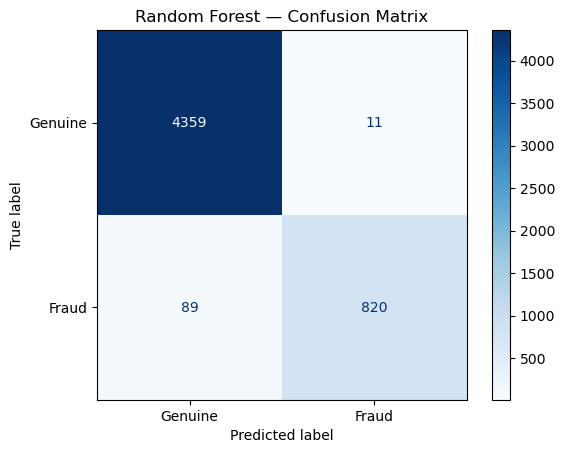

In [19]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fraud'])
disp.plot(cmap='Blues')
plt.title("Random Forest — Confusion Matrix")
plt.show()
plt.close()

## 4.20 Precision-Recall Curve and PR-AUC

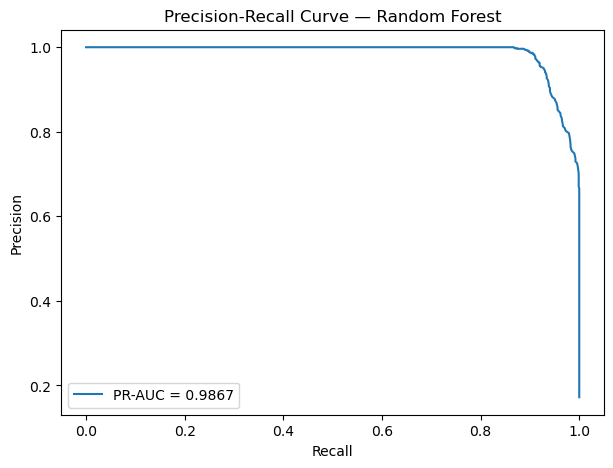

PR-AUC: 0.986708188502651


In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)
pr_auc = auc(recall, precision)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest")
plt.legend()
plt.show()
plt.close()

print("PR-AUC:", pr_auc)

## 4.21 Save Final Model and Artifacts

In [21]:
joblib.dump(rf, "../artifacts/final_model.joblib")
joblib.dump(X_train.columns.tolist(), "../artifacts/feature_columns.joblib")

print("Model and feature columns saved")

Model and feature columns saved


## 4.22 Risk Score Thresholds

In [22]:
import json

risk_thresholds = {
    "low": 30,
    "medium": 70,
    "high": 100
}

with open("../artifacts/risk_thresholds.json", "w") as f:
    json.dump(risk_thresholds, f, indent=4)

print("Risk thresholds saved")

Risk thresholds saved


## 4.23 Model Training Summary

- Discovered additional leakage beyond EDA findings during model training: `merchant_id_freq` (perfect leak, 100% fraud at frequency=1), `device_id_freq` (soft leak, 80% fraud concentration at frequency=1), `receiver_account_age` (sharp leak, 85% fraud only in lowest bin)
- Verified `receiver_transaction_history` is a genuine signal (gradual gradient pattern, not a deterministic split) via diagnostic test — model performance dropped but did not collapse without it
- Final feature count: 18 (after additional leakage removal during training phase)
- Trained and compared 3 models via 5-fold CV: Logistic Regression (0.9931), Random Forest (0.9964), XGBoost (0.9956)
- Selected Random Forest as final model — highest mean ROC-AUC, lowest variance across folds
- Test set performance: ROC-AUC 0.9967, PR-AUC 0.9867
- Saved final_model.joblib, updated feature_columns.joblib, and risk_thresholds.json to artifacts/

## 4.24 SHAP Explainability

In [23]:
X_sample = X_test.sample(n=500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

print("SHAP values computed for", X_sample.shape[0], "samples")

SHAP values computed for 500 samples


## 4.25 SHAP Global Feature Importance

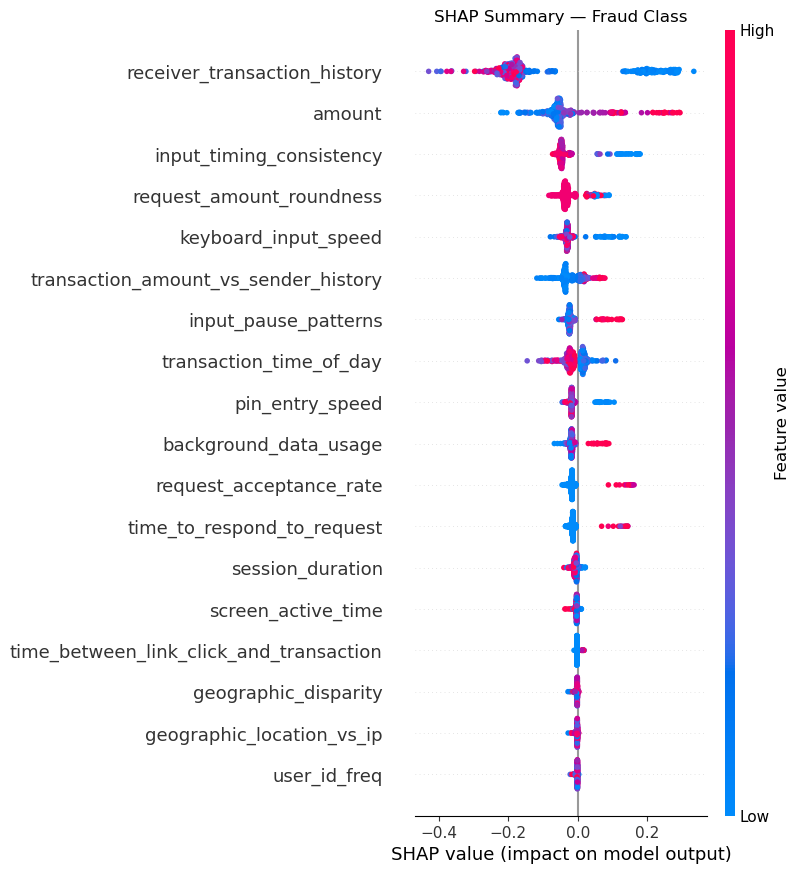

In [24]:
shap.summary_plot(shap_values[:, :, 1], X_sample, show=False)
plt.title("SHAP Summary — Fraud Class")
plt.show()
plt.close()

## 4.26 SHAP Local Explanation (Single Prediction)

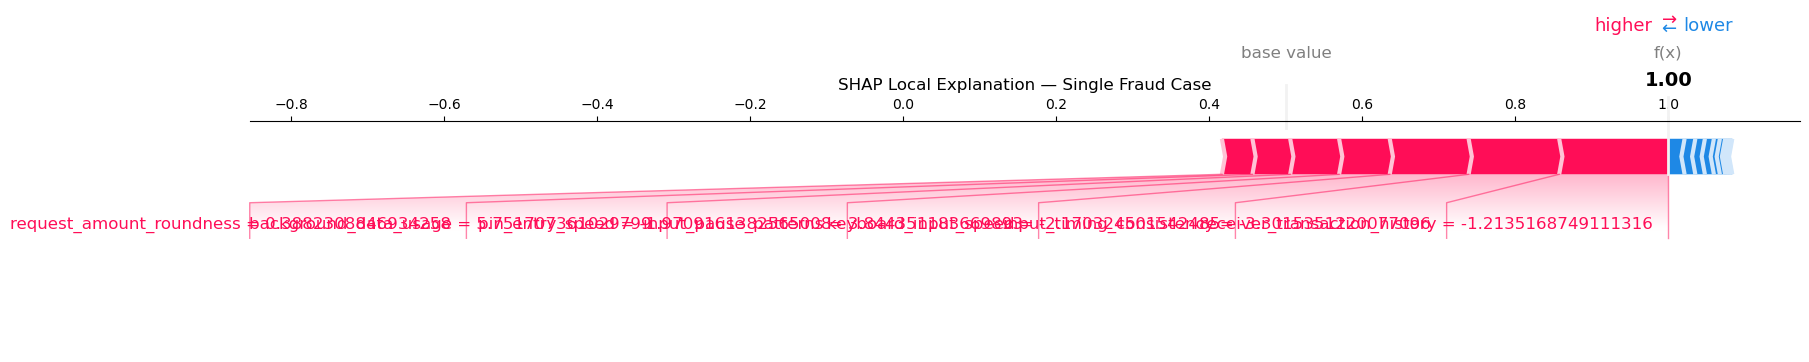

In [25]:
fraud_idx = y_test[y_test == 1].index[0]
sample_idx = X_test.index.get_loc(fraud_idx)

X_single = X_test.loc[[fraud_idx]]
shap_values_single = explainer.shap_values(X_single)

shap.force_plot(
    explainer.expected_value[1],
    shap_values_single[0, :, 1],
    X_single.iloc[0],
    matplotlib=True,
    show=False
)
plt.title("SHAP Local Explanation — Single Fraud Case")
plt.show()
plt.close()

## 4.27 SHAP Summary

- SHAP TreeExplainer used on a 500-sample subset of the test set
- Explainer object is not saved as an artifact — it will be regenerated dynamically at inference time using the saved model, since SHAP explainers can be version-fragile to pickle
- Global feature importance and local (single-prediction) explanations both generated successfully
- Explainer will be regenerated in `src/explainability.py` for use in the FastAPI prediction endpoint and Streamlit dashboard

## 4.28 Re-fit Scaler on Final 18 Features (Fix for Inference Mismatch)

In [26]:
final_scaler = StandardScaler()
X_train_final_scaled = final_scaler.fit_transform(X_train)

joblib.dump(final_scaler, "../artifacts/preprocessor.joblib")
print("Scaler re-fitted and saved with 18 features")

Scaler re-fitted and saved with 18 features
